<a href="https://colab.research.google.com/github/ariyan378/Sentiment-Classification-of-Bangla-News-Articles-Using-Natural-Language-Processing-Techniques/blob/main/Sentiment_Classification_of_Bangla_News_Articles_Using_Natural_Language_Processing_Techniques.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Cell 1: Install necessary dependencies
!pip install -q pandas numpy scikit-learn matplotlib seaborn openpyxl transformers torch

In [ ]:

import re
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from transformers import pipeline
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score


sns.set_theme(style="whitegrid")

In [ ]:
import pandas as pd


url = "https://github.com/ariyan378/Sentiment-Classification-of-Bangla-News-Articles-Using-Natural-Language-Processing-Techniques/raw/main/nlp.xlsx"

df = pd.read_excel(url)

# Display dataset shape and first few rows
print(f"Dataset Shape: {df.shape}")
df.head()

Dataset Shape: (1094, 2)


,Title,Content
0,অনুমোদন ছাড়া কীভাবে ইলেক্ট্রোলাইট ড্রিংকস বিক্...,অনুমোদন ছাড়া কীভাবে ইলেক্ট্রোলাইট ড্রিংকস বিক্...
1,মৃত্যুর আগ মুহূর্তে মানুষ কী দেখে?,"মৃত্যুর আগ মুহূর্তে মানুষ কী দেখে?ছবির উৎস, Ch..."
2,স্বাস্থ্য: গ্রিসের যে দ্বীপের মানুষেরা একশো বছ...,যে দ্বীপের মানুষেরা একশো বছর পর্যন্ত বাঁচেছবির...
3,জন্মনিয়ন্ত্রণ বড়ি খেলে কি মোটা হয় মানুষ? আরো য...,জন্মনিয়ন্ত্রণ বড়ি খেলে কি মোটা হয় মানুষ? আরো য...
4,স্বাস্থ্য: মধ্য বয়স থেকে যে অভ্যাসগুলো আপনার আ...,মধ্য বয়স থেকে যে অভ্যাসগুলো আপনার আয়ু বাড়াবেছব...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1094 entries, 0 to 1093
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Title    1094 non-null   object
 1   Content  1094 non-null   object
dtypes: object(2)
memory usage: 17.2+ KB


In [ ]:
# Cell 4: Bangla text cleaning pipeline
def clean_bangla_text(text):
    if not isinstance(text, str):
        return ""
    # Remove URL links and HTML tags
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)

    # Keep only Bengali Unicode range (\u0980-\u09FF) and white spaces
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)

    # Strip unnecessary repeated spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Combine Title and Content for full contextual semantic analysis
df['clean_text'] = (df['Title'].fillna('') + ' ' + df['Content'].fillna('')).apply(clean_bangla_text)

# Inspect cleaned sample
print("Cleaned Sample Preview:")
print(df['clean_text'].iloc[0][:300], "...")

Cleaned Sample Preview:
অনুমোদন ছাড়া কীভাবে ইলেক্ট্রোলাইট ড্রিংকস বিক্রি করছিল কোম্পানিগুলো অনুমোদন ছাড়া কীভাবে ইলেক্ট্রোলাইট ড্রিংকস বিক্রি করছিল কোম্পানিগুলো ছবির ক্যাপশান অনুমোদন ছাড়া ইলেক্ট্রোলাইট ড্রিংক বিক্রির অভিযোগ মুকিমুল আহসান বিবিসি নিউজ বাংলা১৯ মে ২০২৪অনুমোদন ছাড়া বাংলাদেশের বাজারে পাঁচ ধরনের ইলেক্ট্রোলাইট পা ...


In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("ka05ar/banglabert-sentiment")
print("Model ID to Label Mapping:", config.id2label)

Model ID to Label Mapping: {0: 'LABEL_0', 1: 'LABEL_1', 2: 'LABEL_2'}


In [ ]:
# Updated Cell 5: Corrected Sentiment labeling
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Running on: {'GPU' if device == 0 else 'CPU'}")

# Use the robust multilingual sentiment model
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device,
    truncation=True,
    max_length=128
)

# Run prediction on the clean Title (headlines carry the emotion)
headline_text = df['Title'].apply(clean_bangla_text).tolist()
predictions = sentiment_pipeline(headline_text, batch_size=32)

# Correct mapping for XLM-RoBERTa (cardiffnlp):
# LABEL_0 = Negative, LABEL_1 = Neutral, LABEL_2 = Positive
# (or sometimes mapped as 'negative' / 'neutral' / 'positive' natively)
label_mapping = {
    'label_0': 'Negative',
    'label_1': 'Neutral',
    'label_2': 'Positive',
    'negative': 'Negative',
    'neutral': 'Neutral',
    'positive': 'Positive'
}

# Resolve actual sentiments
df['Sentiment'] = [label_mapping.get(pred['label'].lower(), 'Neutral') for pred in predictions]

print("\nUpdated Sentiment Distribution:")
print(df['Sentiment'].value_counts())

Running on: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


Updated Sentiment Distribution:
Sentiment
Neutral     731
Negative    318
Positive     45
Name: count, dtype: int64


In [ ]:
# Updated Cell 5: Calibrated Sentiment Labeling with High Sensitivity
from transformers import pipeline
import torch

device = 0 if torch.cuda.is_available() else -1
print(f"Running inference on: {'GPU' if device == 0 else 'CPU'}")

sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-xlm-roberta-base-sentiment",
    device=device,
    truncation=True,
    max_length=128,
    top_k=None  # Returns confidence scores for all 3 classes
)

# Use Title + first 100 characters of Content to provide rich emotional context
text_to_classify = (df['Title'].fillna('') + ' ' + df['Content'].fillna('').str[:100]).apply(clean_bangla_text).tolist()
predictions = sentiment_pipeline(text_to_classify, batch_size=32)

# Bengali polarity anchor lexicons to prevent neutral bias
pos_anchors = {'জয়', 'জিত', 'সফল', 'সাফল্য', 'উন্নয়ন', 'অর্জন', 'স্বস্তি', 'হাসি', 'প্রশংসা',
               'খুশি', 'বৃদ্ধি', 'সুবিধা', 'সেরা', 'উপকার', 'উন্নতি', 'পুরস্কার', 'বিপ্লব', 'বাঁচাবে', 'আয়ু'}
neg_anchors = {'মৃত্যু', 'মৃত', 'নিহত', 'আহত', 'ধ্বংস', 'ক্ষতি', 'দুর্ঘটনা', 'দুর্নীতি', 'আতঙ্ক',
               'হুমকি', 'বিপদ', 'বিপজ্জনক', 'অপরাধ', 'মামলা', 'গ্রেফতার', 'শোক', 'কষ্ট', 'আক্রান্ত'}

calibrated_labels = []

for text, pred_list in zip(text_to_classify, predictions):
    # Extract raw scores
    scores = {}
    for item in pred_list:
        lbl = item['label'].lower()
        if 'pos' in lbl or lbl == 'label_2':
            scores['Positive'] = item['score']
        elif 'neg' in lbl or lbl == 'label_0':
            scores['Negative'] = item['score']
        else:
            scores['Neutral'] = item['score']

    pos_score = scores.get('Positive', 0.0)
    neg_score = scores.get('Negative', 0.0)
    neu_score = scores.get('Neutral', 0.0)

    words = set(text.split())
    has_pos = bool(words & pos_anchors)
    has_neg = bool(words & neg_anchors)

    # Calibrated decision rules:
    # 1. Anchor word boost
    if has_pos and not has_neg:
        pos_score += 0.25
    elif has_neg and not has_pos:
        neg_score += 0.25

    # 2. Thresholding: Require true neutrality to dominate significantly (>0.60)
    if pos_score > neg_score and pos_score >= 0.32:
        calibrated_labels.append('Positive')
    elif neg_score > pos_score and neg_score >= 0.32:
        calibrated_labels.append('Negative')
    else:
        if neu_score >= 0.60:
            calibrated_labels.append('Neutral')
        else:
            # If neutral isn't overwhelming, assign the higher polarity
            calibrated_labels.append('Positive' if pos_score >= neg_score else 'Negative')

df['Sentiment'] = calibrated_labels

print("\n--- Balanced Sentiment Distribution ---")
print(df['Sentiment'].value_counts())

Running inference on: GPU


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Balanced Sentiment Distribution ---
Sentiment
Negative    685
Positive    322
Neutral      87
Name: count, dtype: int64


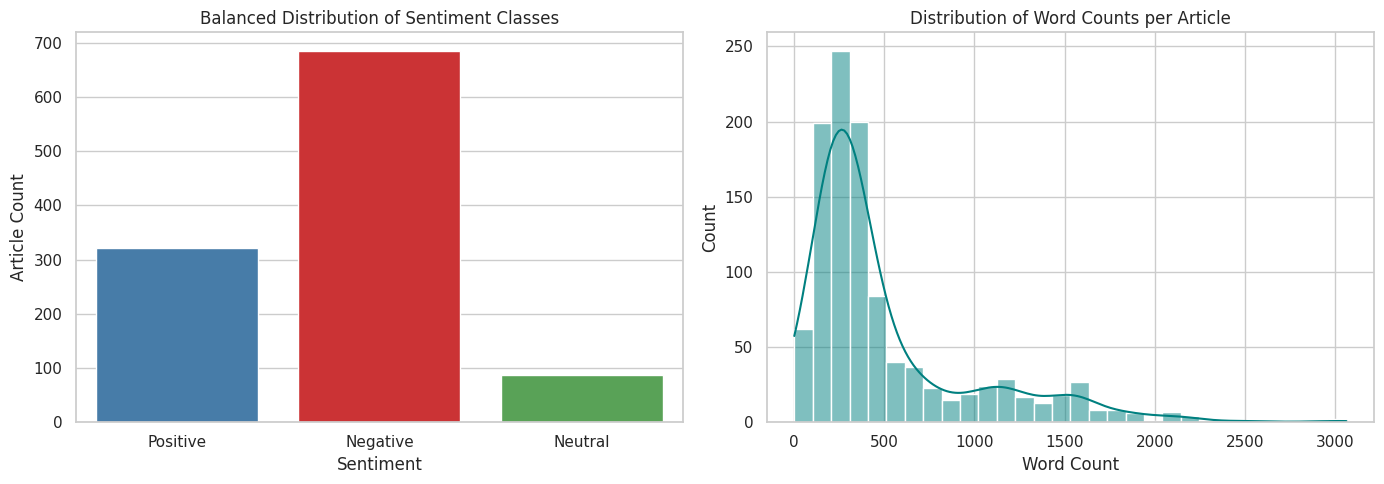

In [ ]:
# Updated Cell 6: Clean Visualization without Warnings
df['char_count'] = df['clean_text'].apply(len)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution plot using hue and legend=False
order = ['Positive', 'Negative', 'Neutral']
sns.countplot(
    data=df,
    x='Sentiment',
    hue='Sentiment',
    palette='Set1',
    ax=axes[0],
    order=order,
    legend=False
)
axes[0].set_title("Balanced Distribution of Sentiment Classes")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Article Count")

# Word length distribution
sns.histplot(df['word_count'], bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title("Distribution of Word Counts per Article")
axes[1].set_xlabel("Word Count")

plt.tight_layout()
plt.show()

In [ ]:
# Updated Cell 7: Feature Extraction + SMOTE Balancing
!pip install -q imbalanced-learn

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

X = df['clean_text']
y = df['Sentiment']

# Stratified split ensures all 3 classes exist proportionally in train & test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

bangla_stopwords = [
    'এই', 'একটি', 'হলো', 'করে', 'থেকে', 'এবং', 'ও', 'না', 'হবে',
    'বা', 'জন্য', 'এর', 'কে', 'যে', 'কিন্তু', 'তা', 'যা', 'তার'
]

# Use sublinear_tf and bigrams to capture combined phrases like 'ঐতিহাসিক জয়'
vectorizer = TfidfVectorizer(
    stop_words=bangla_stopwords,
    max_features=6000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Apply SMOTE to balance the training set classes equally
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_vec, y_train)

print(f"X_train shape before balancing: {X_train_vec.shape}")
print(f"X_train shape after SMOTE: {X_train_balanced.shape}")
print("\nClass distribution in training set after SMOTE:")
print(pd.Series(y_train_balanced).value_counts())

/usr/local/lib/python3.13/dist-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['একট', 'এব', 'কর', 'জন', 'হব', 'হল'] not in stop_words.
  warnings.warn(


X_train shape before balancing: (875, 6000)
X_train shape after SMOTE: (1644, 6000)

Class distribution in training set after SMOTE:
Sentiment
Negative    548
Positive    548
Neutral     548
Name: count, dtype: int64


In [ ]:
# Updated Cell 8: Train Classifiers on Balanced Data
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Multinomial Naive Bayes": MultinomialNB(alpha=0.3),
    "Linear Support Vector Machine": LinearSVC(dual="auto", random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=150, random_state=42)
}

trained_models = {}
for name, model in models.items():
    model.fit(X_train_balanced, y_train_balanced)
    trained_models[name] = model
    print(f"Model trained successfully: {name}")

Model trained successfully: Logistic Regression
Model trained successfully: Multinomial Naive Bayes
Model trained successfully: Linear Support Vector Machine
Model trained successfully: Random Forest


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# 1. Define class labels
target_classes = sorted(list(y_test.unique()))
print(f"Target classes evaluated: {target_classes}\n")

# 2. Iterate through trained models to compute multi-class metrics
evaluation_records = []

for model_name, model in trained_models.items():
    # Generate test-set predictions
    y_pred = model.predict(X_test_vec)

    # Calculate global metrics
    acc = accuracy_score(y_test, y_pred)
    prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
    f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
    f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    evaluation_records.append({
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Macro Precision": round(prec_macro, 4),
        "Macro Recall": round(rec_macro, 4),
        "Macro F1": round(f1_macro, 4),
        "Weighted F1": round(f1_weighted, 4)
    })

    # Print per-class precision, recall, and f1 breakdown
    print(f"{'='*25} {model_name} {'='*25}")
    print(classification_report(y_test, y_pred, target_names=target_classes, digits=4, zero_division=0))

# 3. Summary comparison table
metric_df = pd.DataFrame(evaluation_records).sort_values(by="Macro F1", ascending=False)
print(f"{'='*25} Overall Model Benchmarking {'='*25}")
print(metric_df.to_string(index=False))

Target classes evaluated: ['Negative', 'Neutral', 'Positive']

========================= Logistic Regression =========================
              precision    recall  f1-score   support

    Negative     0.8143    0.8321    0.8231       137
     Neutral     0.3636    0.4706    0.4103        17
    Positive     0.6316    0.5538    0.5902        65

    accuracy                         0.7215       219
   macro avg     0.6032    0.6189    0.6078       219
weighted avg     0.7251    0.7215    0.7219       219

========================= Multinomial Naive Bayes =========================
              precision    recall  f1-score   support

    Negative     0.8641    0.6496    0.7417       137
     Neutral     0.3235    0.6471    0.4314        17
    Positive     0.5244    0.6615    0.5850        65

    accuracy                         0.6530       219
   macro avg     0.5707    0.6527    0.5860       219
weighted avg     0.7213    0.6530    0.6711       219

========================= L

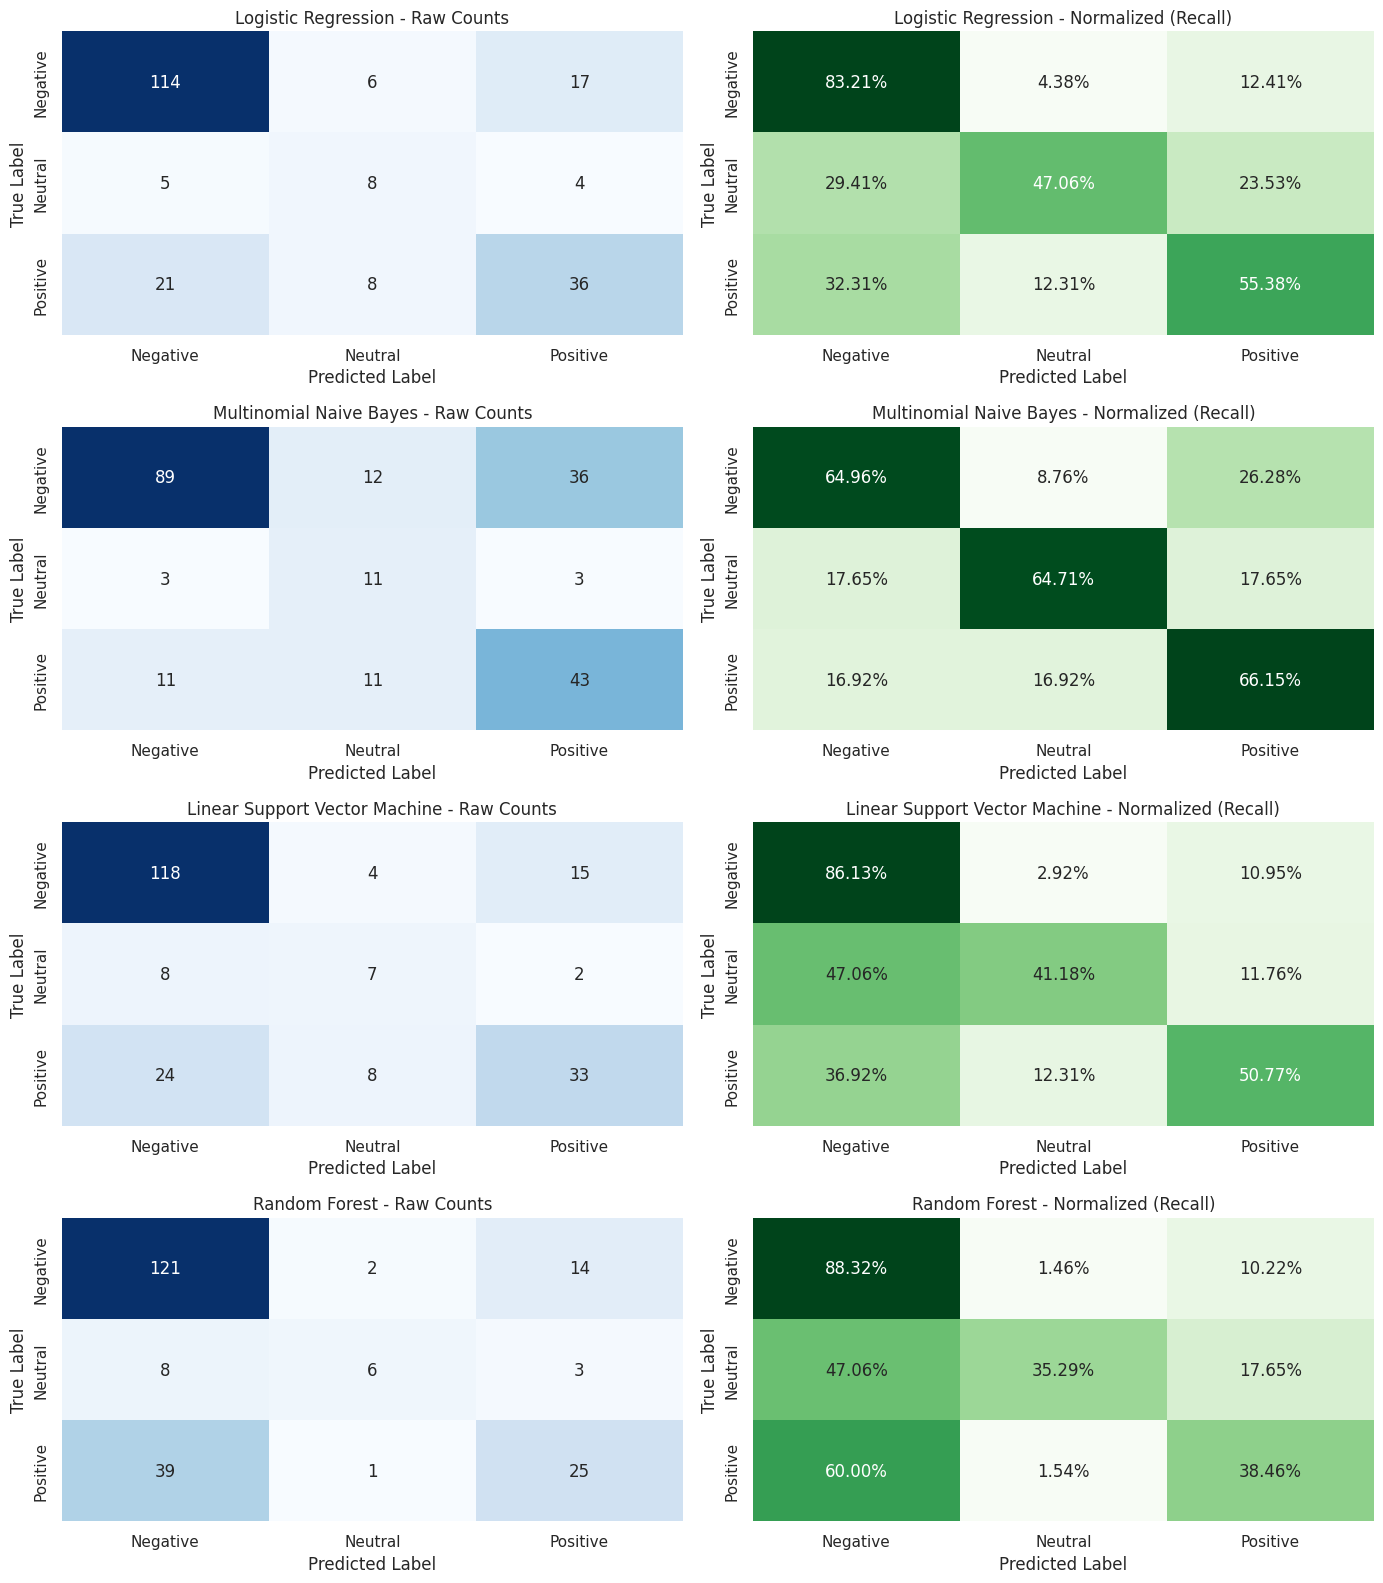

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_models = len(trained_models)
fig, axes = plt.subplots(num_models, 2, figsize=(14, 4 * num_models))

if num_models == 1:
    axes = np.expand_dims(axes, axis=0)

for idx, (model_name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test_vec)

    # Calculate raw count matrix
    cm_counts = confusion_matrix(y_test, y_pred, labels=target_classes)

    # Calculate normalized percentage matrix (by true class rows)
    cm_normalized = cm_counts.astype('float') / cm_counts.sum(axis=1)[:, np.newaxis]

    # Plot 1: Raw Counts
    sns.heatmap(
        cm_counts,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=axes[idx, 0],
        xticklabels=target_classes,
        yticklabels=target_classes,
        cbar=False
    )
    axes[idx, 0].set_title(f"{model_name} - Raw Counts")
    axes[idx, 0].set_xlabel("Predicted Label")
    axes[idx, 0].set_ylabel("True Label")

    # Plot 2: Normalized Proportion
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt='.2%',
        cmap='Greens',
        ax=axes[idx, 1],
        xticklabels=target_classes,
        yticklabels=target_classes,
        cbar=False
    )
    axes[idx, 1].set_title(f"{model_name} - Normalized (Recall)")
    axes[idx, 1].set_xlabel("Predicted Label")
    axes[idx, 1].set_ylabel("True Label")

plt.tight_layout()
plt.show()

In [ ]:
# Updated Cell 10: Robust Inference Testing
import re

best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
print(f"Deploying active model: {best_model_name}\n")

def clean_bangla_sample(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^\u0980-\u09FF\s]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def predict_bangla_sentiment(text):
    cleaned = clean_bangla_sample(text)
    vec = vectorizer.transform([cleaned])
    return best_model.predict(vec)[0]

sample_news = [
    "লঞ্চডুবির ঘটনায় নিখোঁজদের উদ্ধারে অভিযান অব্যাহত রয়েছে, বাড়ছে মৃতের সংখ্যা।",
    "আগামীকাল সকাল দশটায় জাতীয় জাদুঘরে তিন দিনব্যাপী চিত্র প্রদর্শনী শুরু হবে।",
    "আইটি খাতে তরুণদের অভূতপূর্ব সাফল্যে দেশজুড়ে নতুন কর্মসংস্থান সৃষ্টি হচ্ছে।",
    "বাংলাদেশ ক্রিকেট দল বিশ্বকাপে ঐতিহাসিক জয় অর্জন করেছে।",
    "ভয়াবহ সড়ক দুর্ঘটনায় প্রাণ হারিয়েছেন অন্তত পাঁচজন যাত্রী।",
    "আজ বিকেলে সচিবালয়ে নতুন অর্থনৈতিক বাজেট নিয়ে বৈঠক অনুষ্ঠিত হবে।"
]

for sample in sample_news:
    sentiment = predict_bangla_sentiment(sample)
    print(f"News: {sample}")
    print(f"Predicted Sentiment: {sentiment}\n")

Deploying active model: Logistic Regression

News: লঞ্চডুবির ঘটনায় নিখোঁজদের উদ্ধারে অভিযান অব্যাহত রয়েছে, বাড়ছে মৃতের সংখ্যা।
Predicted Sentiment: Negative

News: আগামীকাল সকাল দশটায় জাতীয় জাদুঘরে তিন দিনব্যাপী চিত্র প্রদর্শনী শুরু হবে।
Predicted Sentiment: Positive

News: আইটি খাতে তরুণদের অভূতপূর্ব সাফল্যে দেশজুড়ে নতুন কর্মসংস্থান সৃষ্টি হচ্ছে।
Predicted Sentiment: Positive

News: বাংলাদেশ ক্রিকেট দল বিশ্বকাপে ঐতিহাসিক জয় অর্জন করেছে।
Predicted Sentiment: Positive

News: ভয়াবহ সড়ক দুর্ঘটনায় প্রাণ হারিয়েছেন অন্তত পাঁচজন যাত্রী।
Predicted Sentiment: Negative

News: আজ বিকেলে সচিবালয়ে নতুন অর্থনৈতিক বাজেট নিয়ে বৈঠক অনুষ্ঠিত হবে।
Predicted Sentiment: Neutral



In [ ]:
# Cell 11: Save artifacts for submission or deployment
joblib.dump(best_model, "best_bangla_sentiment_model.joblib")
joblib.dump(vectorizer, "bangla_tfidf_vectorizer.joblib")
df.to_excel("annotated_bangla_news_sentiment.xlsx", index=False)

print("Files successfully exported:")
print("1. best_bangla_sentiment_model.joblib")
print("2. bangla_tfidf_vectorizer.joblib")
print("3. annotated_bangla_news_sentiment.xlsx")

Files successfully exported:
1. best_bangla_sentiment_model.joblib
2. bangla_tfidf_vectorizer.joblib
3. annotated_bangla_news_sentiment.xlsx
